# 06. Ethereum Price Prediction (Optimized)
**Objective:** Train and Evaluate a Directional Prediction Model.
**Input:** `training_data_4h_engineered.csv` (Features prepared in Notebook 04)

This notebook focuses purely on Modeling, using the features (Sentiment Lags, Rolling, RSI) created in the previous step.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os

%matplotlib inline

# Load Data
DATA_PATH = 'training_data_4h_engineered.csv'

if not os.path.exists(DATA_PATH):
    print(f"Error: {DATA_PATH} not found. Please run Notebook 04 first to generate features.")
else:
    df = pd.read_csv(DATA_PATH)
    if 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'])
        df = df.set_index('datetime')
    print(f"Data Loaded. Shape: {df.shape}")
    print(df.head())


Data Loaded. Shape: (613, 17)
                           price       volume  Sentiment Score  sent_lag_1  \
datetime                                                                     
2025-10-11 00:00:00  3808.652039  10121437184        -0.002868   -0.163792   
2025-10-11 04:00:00  3788.644836   7887749120        -0.163330   -0.002868   
2025-10-11 08:00:00  3833.351929   6549282816        -0.056509   -0.163330   
2025-10-11 12:00:00  3826.274048   1013047296        -0.382847   -0.056509   
2025-10-11 16:00:00  3807.995300    485752832        -0.288694   -0.382847   

                     sent_lag_2  sent_lag_3  sent_lag_4  sent_lag_5  \
datetime                                                              
2025-10-11 00:00:00   -0.010105   -0.158246   -0.011719   -0.030321   
2025-10-11 04:00:00   -0.163792   -0.010105   -0.158246   -0.011719   
2025-10-11 08:00:00   -0.002868   -0.163792   -0.010105   -0.158246   
2025-10-11 12:00:00   -0.163330   -0.002868   -0.163792   -0.010105 

In [2]:
# 1. Prepare Features (X) and Target (y)

# Define Features (Must match what was created in Notebook 04)
feature_cols = [
    # Sentiment
    'Sentiment Score', 
    'sent_lag_1', 'sent_lag_2', 'sent_lag_3', 
    'sent_roll_6', 'sent_roll_24',
    # Technicals
    'rsi', 'ret_1h', 'ret_4h', 'volatility_6h',
    'volume'
]

# Ensure features are present
available_feats = [c for c in feature_cols if c in df.columns]
print(f"Using Features: {available_feats}")

X = df[available_feats]
y = df['target_dir']

# Time-Series Split (No random shuffling)
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Train Size: {X_train.shape}, Test Size: {X_test.shape}")


Using Features: ['Sentiment Score', 'sent_lag_1', 'sent_lag_2', 'sent_lag_3', 'sent_roll_6', 'sent_roll_24', 'rsi', 'ret_1h', 'ret_4h', 'volatility_6h', 'volume']
Train Size: (490, 11), Test Size: (123, 11)


In [3]:
# 2. Model Training (Gradient Boosting)

print("Training Model...")
clf = GradientBoostingClassifier(
    n_estimators=200, 
    learning_rate=0.05, 
    max_depth=4, 
    random_state=42
)
clf.fit(X_train, y_train)

# Predictions
preds = clf.predict(X_test)
probs = clf.predict_proba(X_test)[:, 1]

# Evaluation
acc = accuracy_score(y_test, preds)
print(f"Directional Prediction Accuracy: {acc*100:.2f}%")
print("-" * 30)
print(classification_report(y_test, preds))


Training Model...
Directional Prediction Accuracy: 55.28%
------------------------------
              precision    recall  f1-score   support

           0       0.47      0.48      0.48        52
           1       0.61      0.61      0.61        71

    accuracy                           0.55       123
   macro avg       0.54      0.54      0.54       123
weighted avg       0.55      0.55      0.55       123



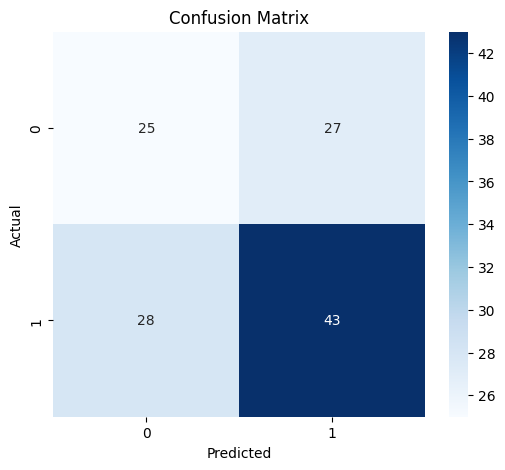

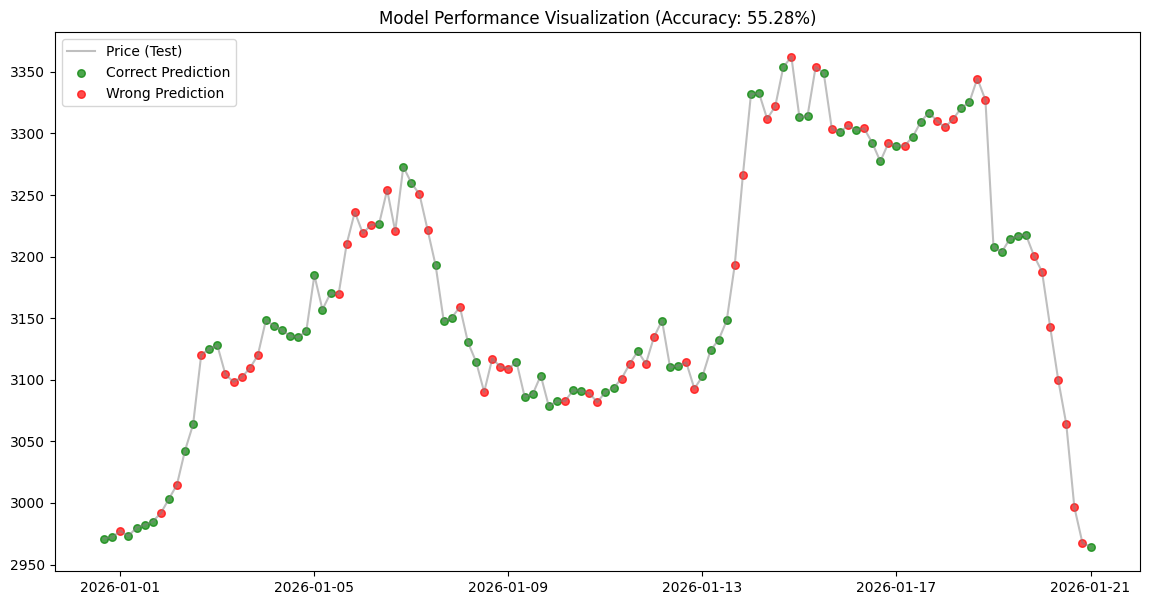

In [4]:
# 3. Visualization

# Confusion Matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Price vs Predictions (Green = Correct, Red = Wrong)
test_dates = df.index[train_size:]
test_prices = df['price'].iloc[train_size:]

plt.figure(figsize=(14, 7))
plt.plot(test_dates, test_prices, label='Price (Test)', color='gray', alpha=0.5)

# Correct Predictions (Filter indices where preds == y_test)
correct_mask = (preds == y_test)
plt.scatter(test_dates[correct_mask], test_prices[correct_mask], color='green', label='Correct Prediction', s=30, alpha=0.7)

# Incorrect Predictions
incorrect_mask = (preds != y_test)
plt.scatter(test_dates[incorrect_mask], test_prices[incorrect_mask], color='red', label='Wrong Prediction', s=30, alpha=0.7)

plt.title(f'Model Performance Visualization (Accuracy: {acc*100:.2f}%)')
plt.legend()
plt.show()
